In [1]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(project_root)

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

from model.relevant_methods import phase_methods

c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm


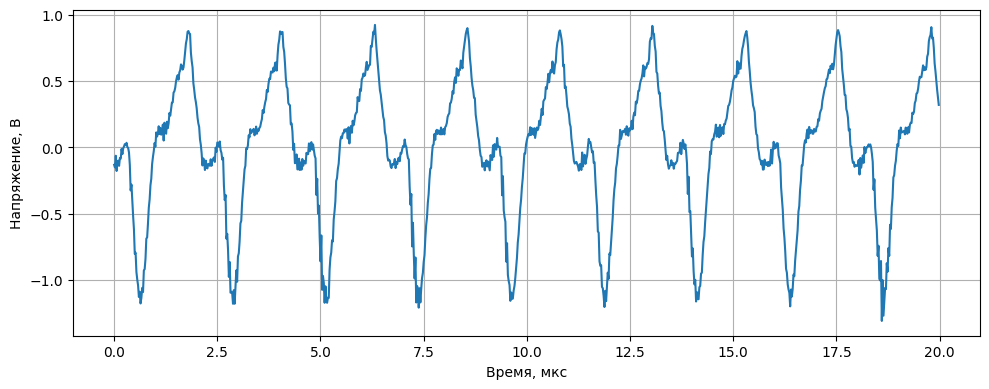

In [2]:
U_path = os.path.join(
    project_root,
    "data",
    "FPGA",
    "stp2.csv"
)

df = pd.read_csv(U_path, skiprows=5)

U_code = (
    df.iloc[:, 1]
    .astype(str)
    .str.split(".")
    .str[0]
    .apply(lambda x: int(x, 2))
    .to_numpy()
)

# Параметры АЦП
fs = 50e6
ADC_BITS = 12
V_MIN = -5.0
V_MAX = 5.0

# Шкала времени
t = np.arange(len(U_code)) / fs

# Перевод кодов АЦП в вольты
U = V_MIN + U_code * (V_MAX - V_MIN) / (2**ADC_BITS - 1)

# При необходимости убрать остаточное постоянное смещение
U_centered = U - np.mean(U)

plt.figure(figsize=(10, 4))
plt.plot(t[:1000] * 1e6, U_centered[:1000])
plt.xlabel("Время, мкс")
plt.ylabel("Напряжение, В")
plt.grid()
plt.tight_layout()
plt.show()

In [3]:
F,V = md.get_spectrum1(t,U_centered)
F_peak_calc = F[np.argmax(V)]
print(F_peak_calc)
T=1/F_peak_calc
T_counts=md.convert_to_counts(t,T)

445502.25802514347


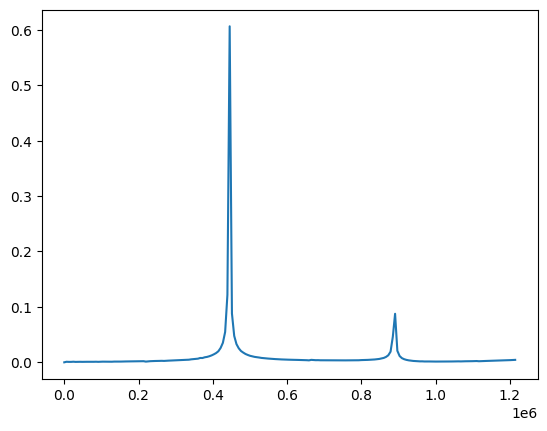

In [4]:
plt.plot(F[:200],V[:200])

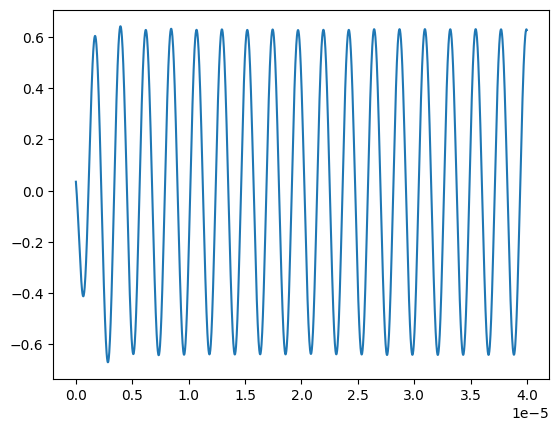

In [6]:
t_f, U_f=md.filter_butter_bandpass(t,U_centered,F_peak_calc,200e3,2)

plt.plot(t_f[:2000], U_f[:2000])